In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [60]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\concrete_data.csv")

In [61]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
820,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,270,67.11
259,212.6,0.0,100.4,159.4,10.4,1003.8,903.8,3,13.33
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29
441,250.0,0.0,95.7,191.8,5.3,948.9,857.2,28,27.22
557,255.5,170.3,0.0,185.7,0.0,1026.6,724.3,7,17.24


In [62]:
df.shape

(1030, 9)

In [63]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [64]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [65]:
X = df.drop('Strength' , axis=1)

In [66]:
y = df.iloc[:,-1]

In [67]:
X.shape

(1030, 8)

In [68]:
X_test , X_train , y_test , y_train = train_test_split(X,y , train_size=0.2)

In [69]:
X_test

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
166,375.0,93.8,0.0,126.6,23.4,852.1,992.6,91
500,491.0,26.0,123.0,201.0,3.9,822.0,699.0,28
632,325.0,0.0,0.0,184.0,0.0,1063.0,783.0,28
154,379.5,151.2,0.0,153.9,15.9,1134.3,605.0,56
695,116.0,173.0,0.0,192.0,0.0,909.8,891.9,28
...,...,...,...,...,...,...,...,...
550,393.0,0.0,0.0,192.0,0.0,940.6,785.6,7
170,388.6,97.1,0.0,157.9,12.1,852.1,925.7,91
290,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,14
316,251.8,0.0,99.9,146.1,12.4,1006.0,899.8,28


## applying without transformation

In [70]:
lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)


r2_score(y_test,y_pred) 

0.6419220996771782

## cross validation

In [71]:
lr = LinearRegression()
np.mean(cross_val_score(lr , X ,y , scoring='r2'))

np.float64(0.4609940491662864)

##  Plotting the distplots without any transformation

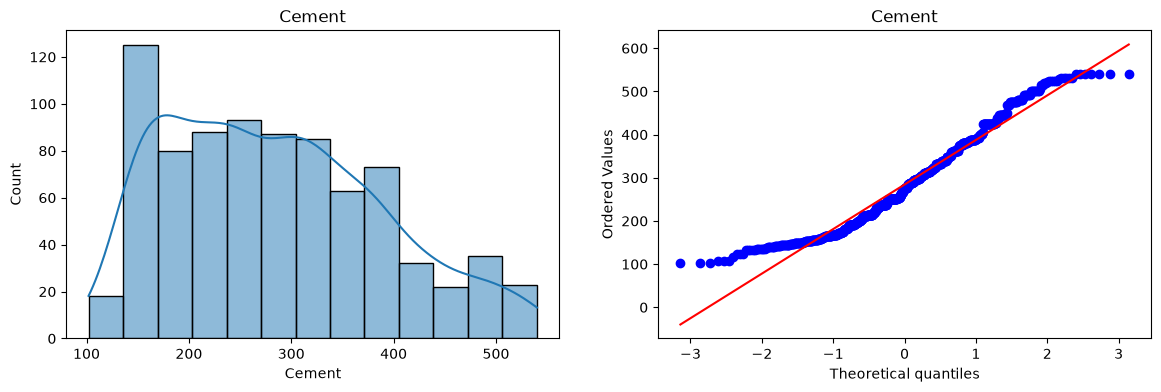

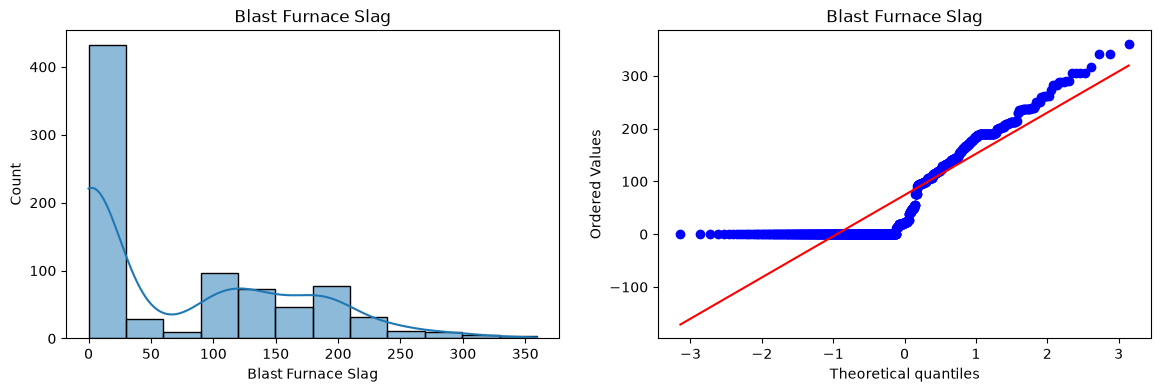

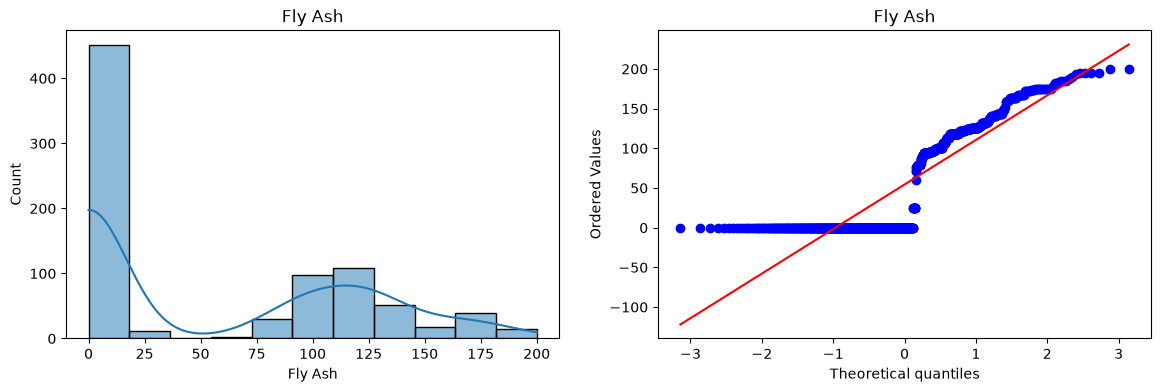

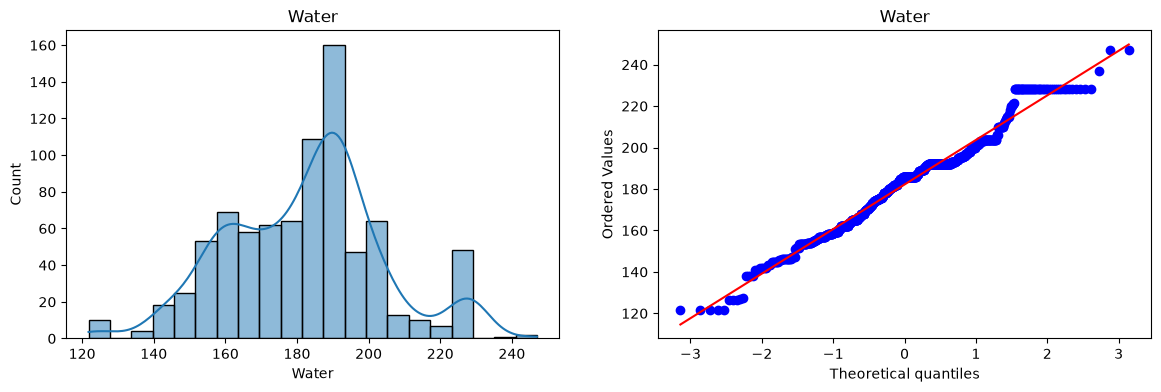

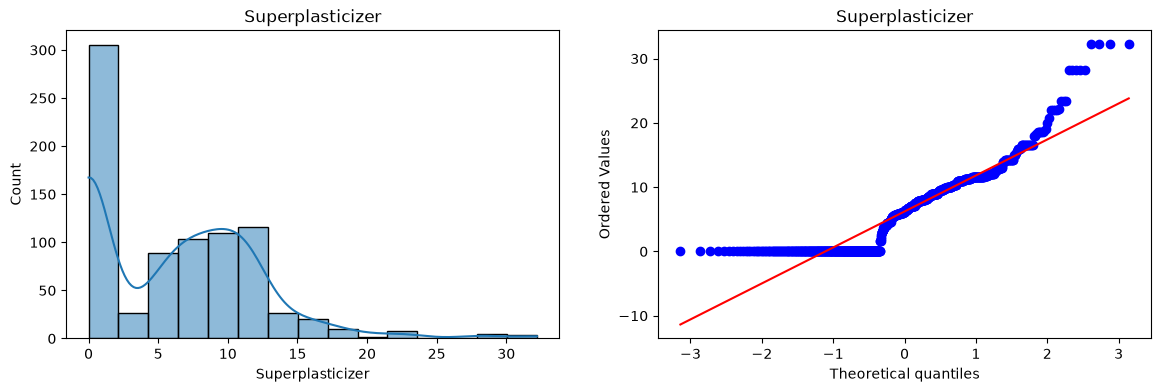

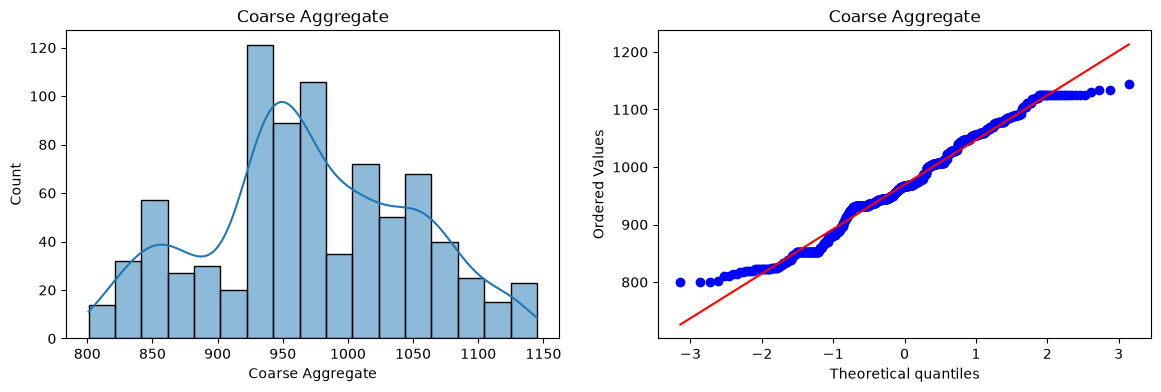

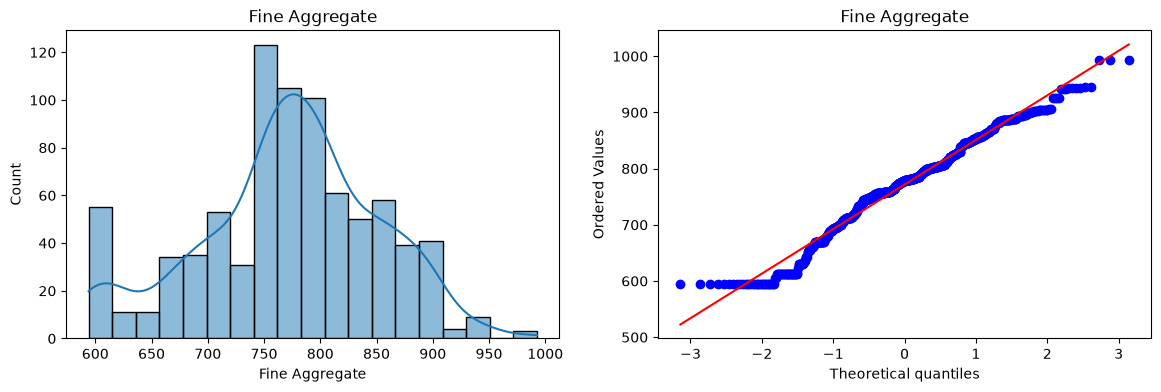

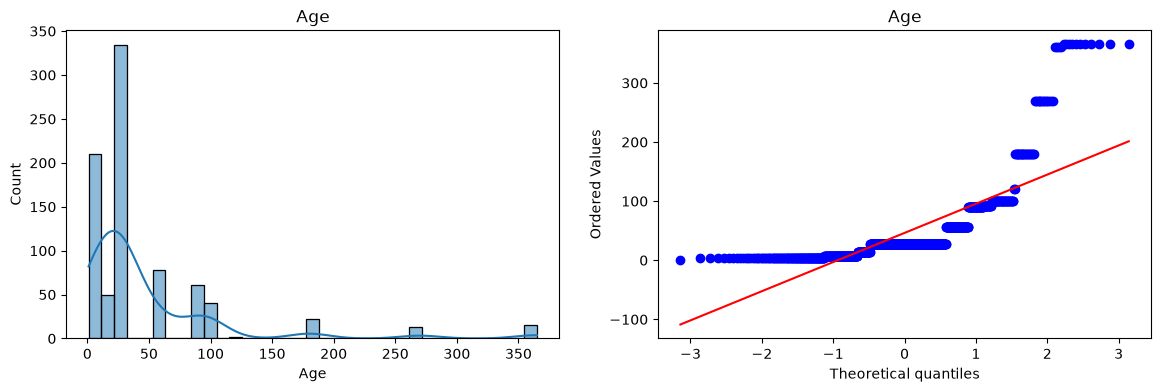

In [72]:
for col in X_train.columns :
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col] , kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()
    

## Applying Box-Cox Transform


In [73]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.190885
1,Blast Furnace Slag,0.027409
2,Fly Ash,-0.030969
3,Water,0.836515
4,Superplasticizer,0.101883
5,Coarse Aggregate,0.961060
6,Fine Aggregate,1.913121
7,Age,0.046356


##  Applying linear regression on transformed data

In [74]:

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8016656845435435

# Applying cross valdation

In [75]:
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X + 0.0000001)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434359)

## before and after comparision for Box-Cox Plot

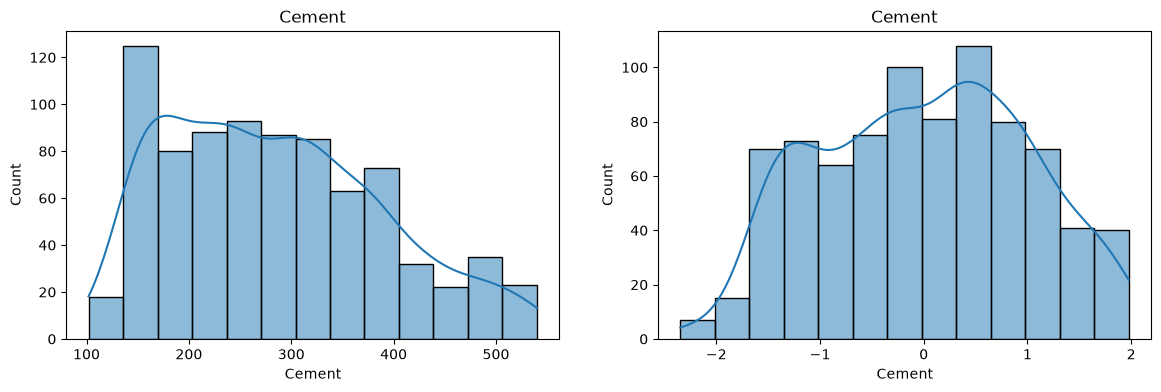

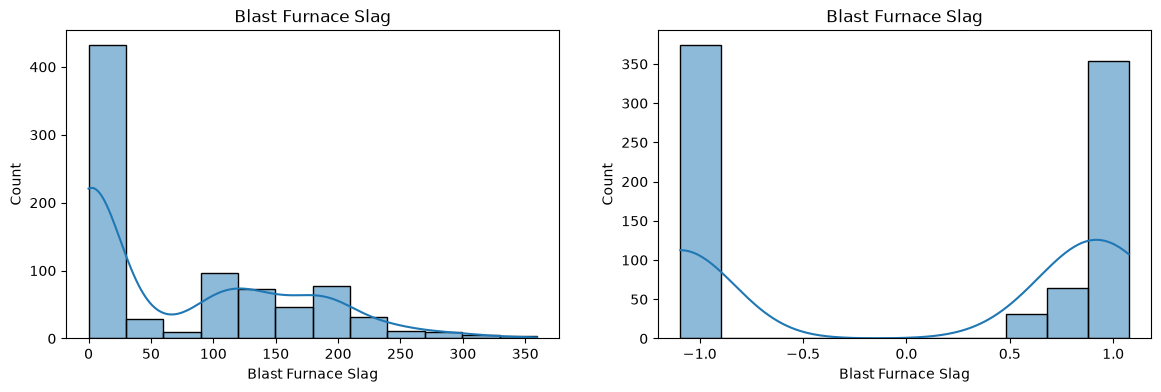

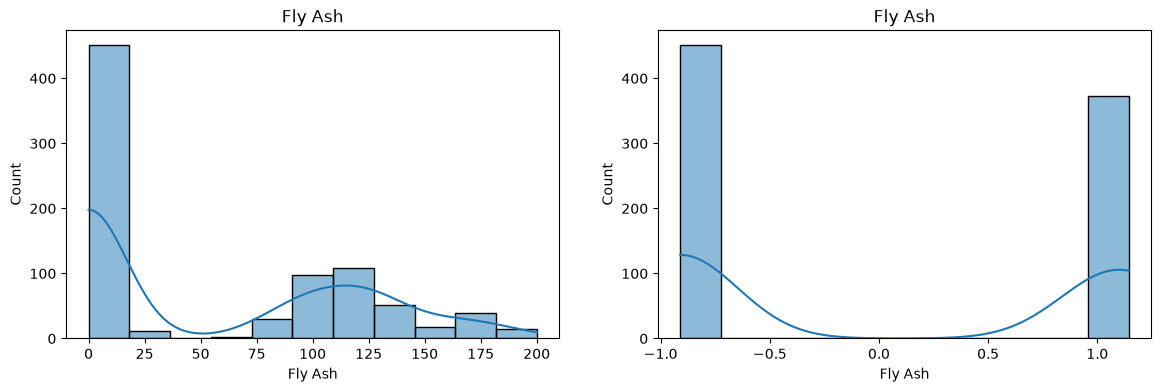

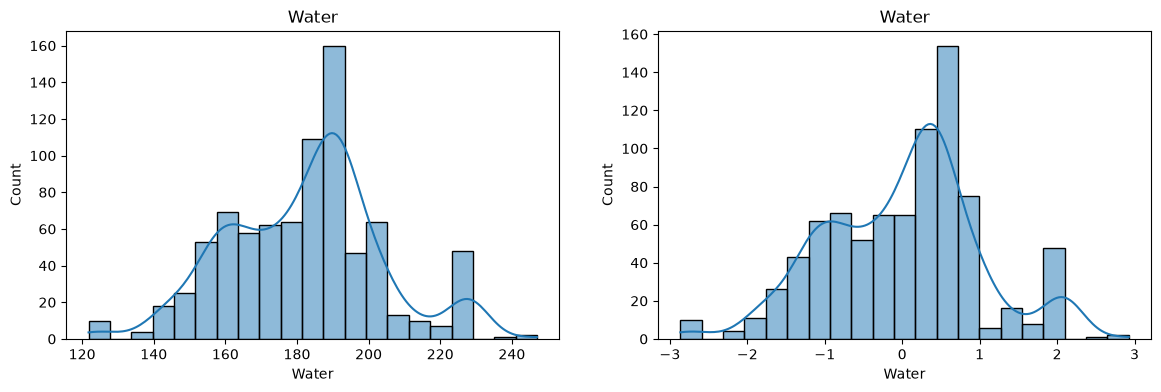

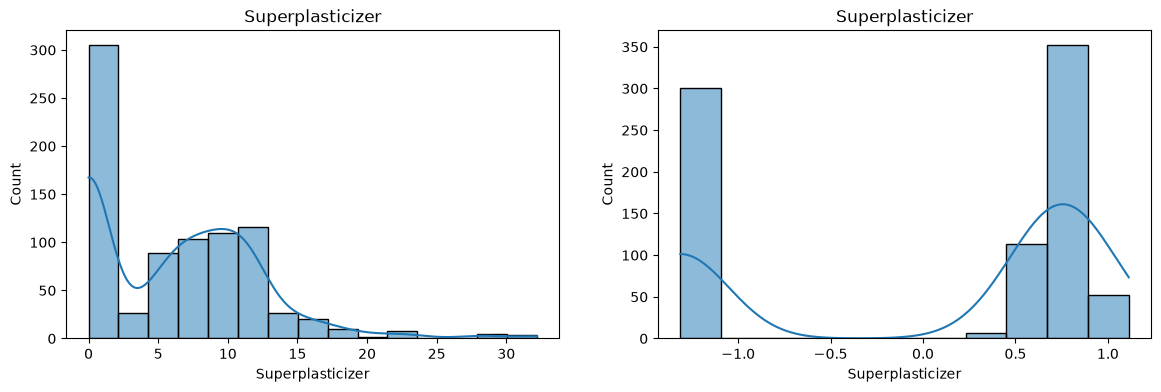

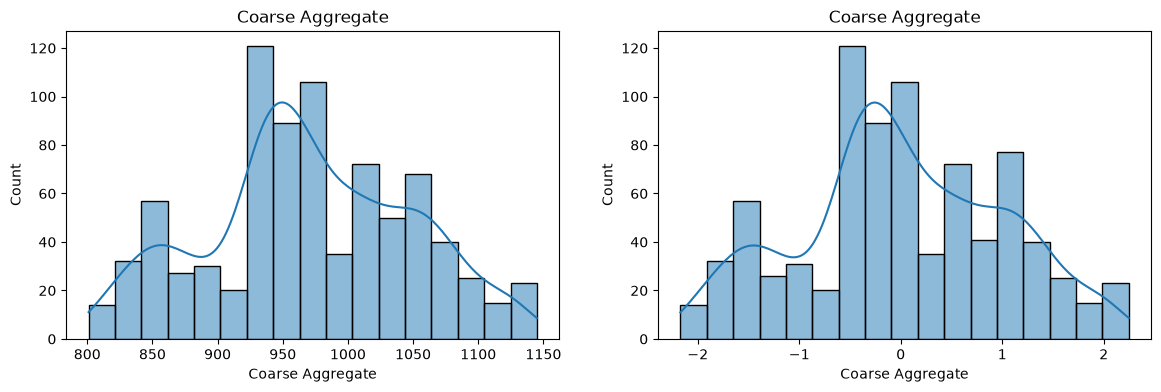

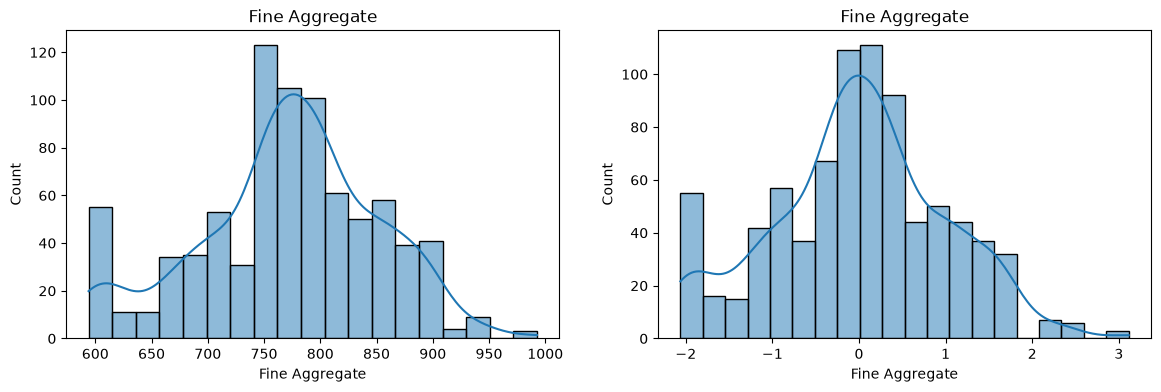

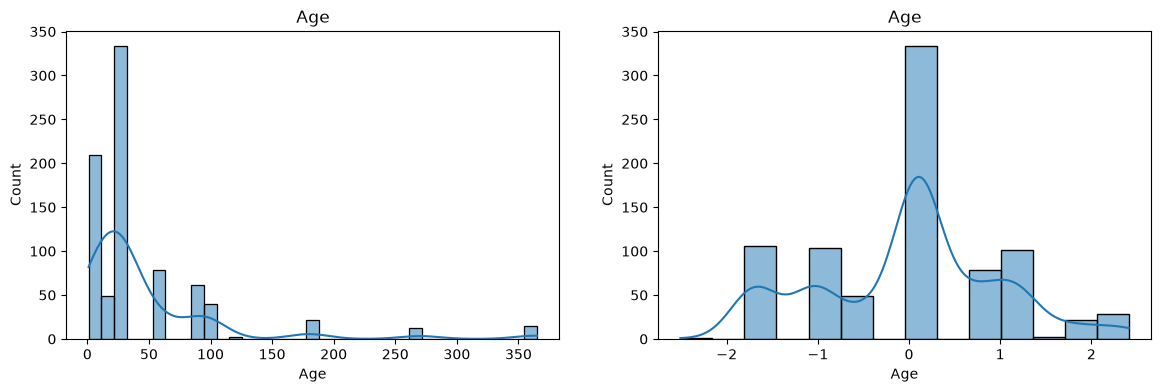

In [79]:
X_train_transformed = pd.DataFrame(X_train_transformed , columns =X_train.columns)
for col in X_train_transformed.columns: 
        plt.figure(figsize=(14,4))
        plt.subplot(121)
        sns.histplot(X_train[col] , kde=True)
        plt.title(col)
    
        plt.subplot(122)
        sns.histplot(X_train_transformed[col] , kde=True)
        plt.title(col)
    
        plt.show()

## Apply Yeo-Johnson transform

In [84]:

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})


0.8090718019353946


,cols,Yeo_Johnson_lambdas
0,Cement,0.188286
1,Blast Furnace Slag,0.022651
2,Fly Ash,-0.130629
3,Water,0.835541
4,Superplasticizer,0.266176
5,Coarse Aggregate,0.961114
6,Fine Aggregate,1.914381
7,Age,-0.000007


In [85]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

In [86]:
 #applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625126992446)

## Before and after comparision for Yeo-Johnson

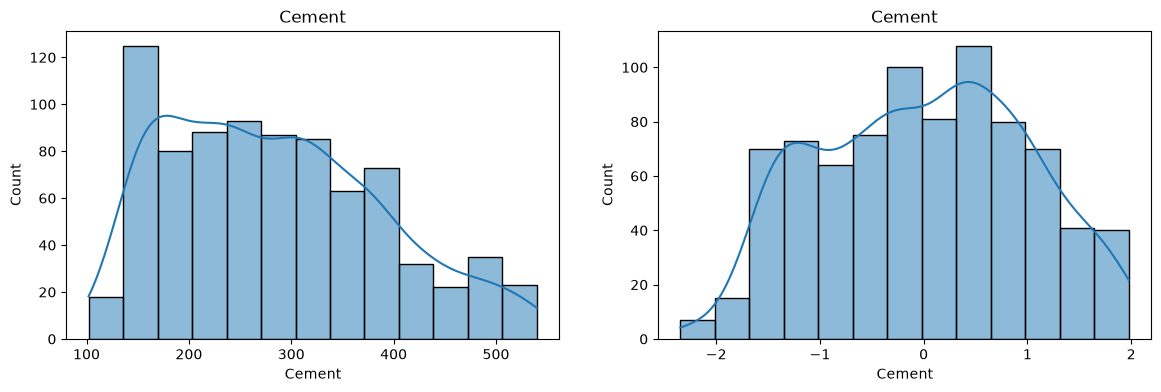

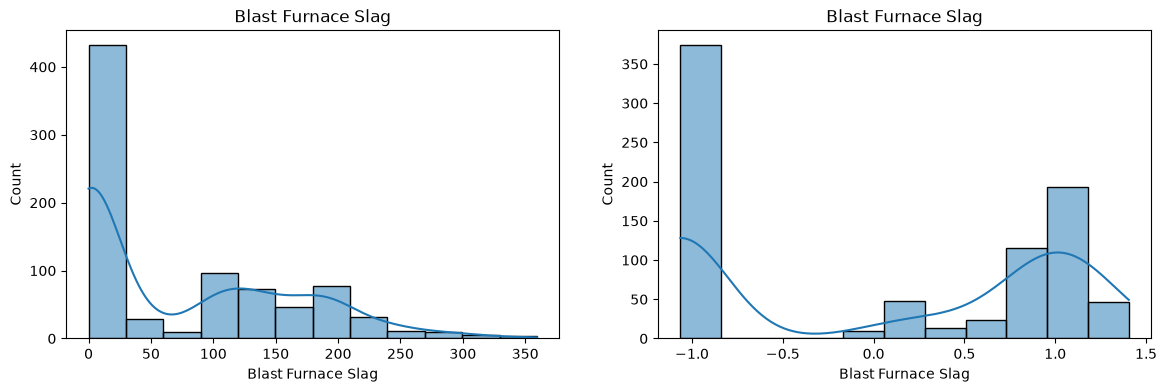

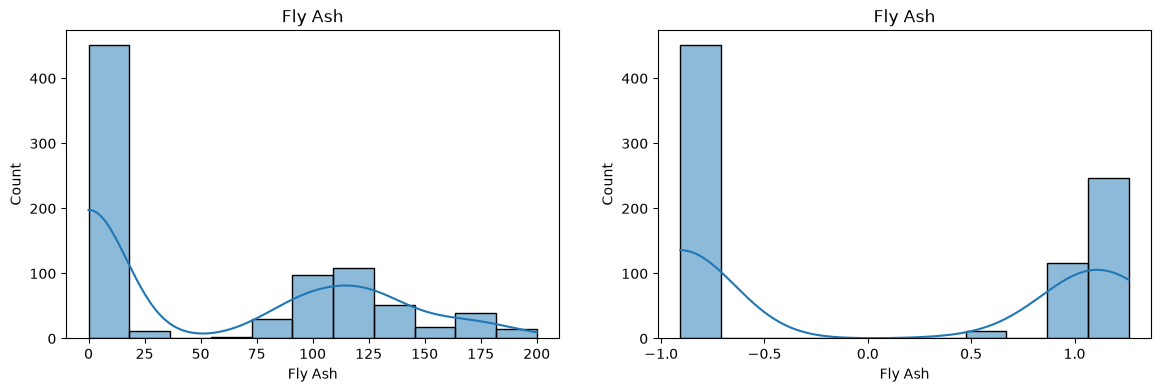

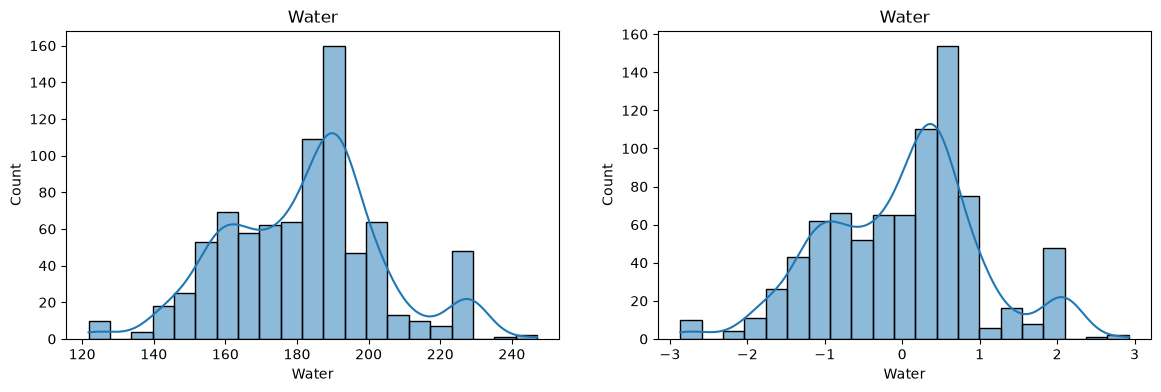

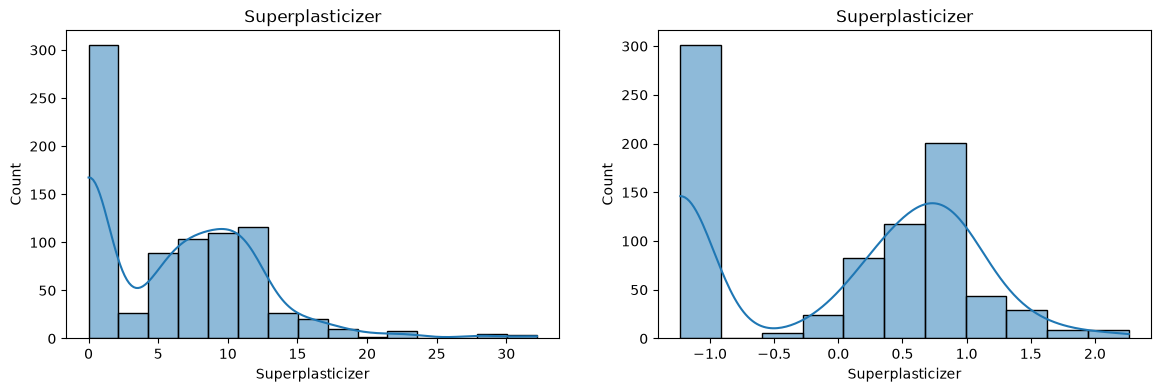

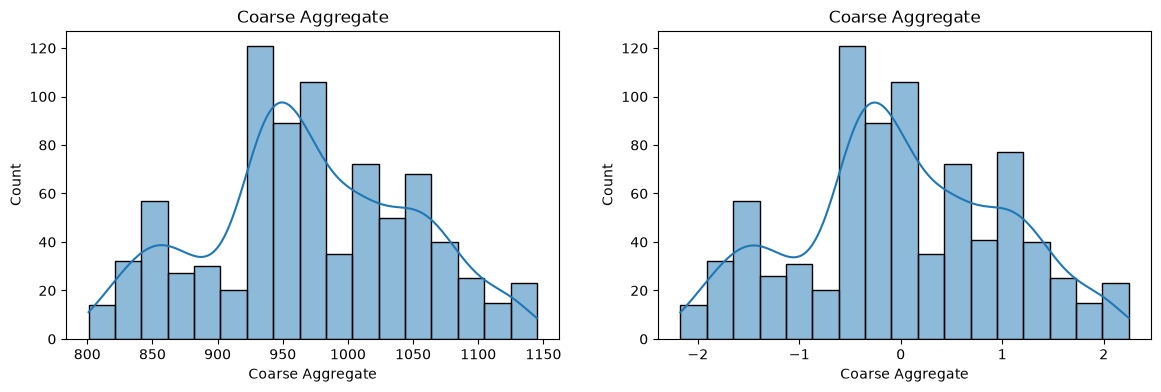

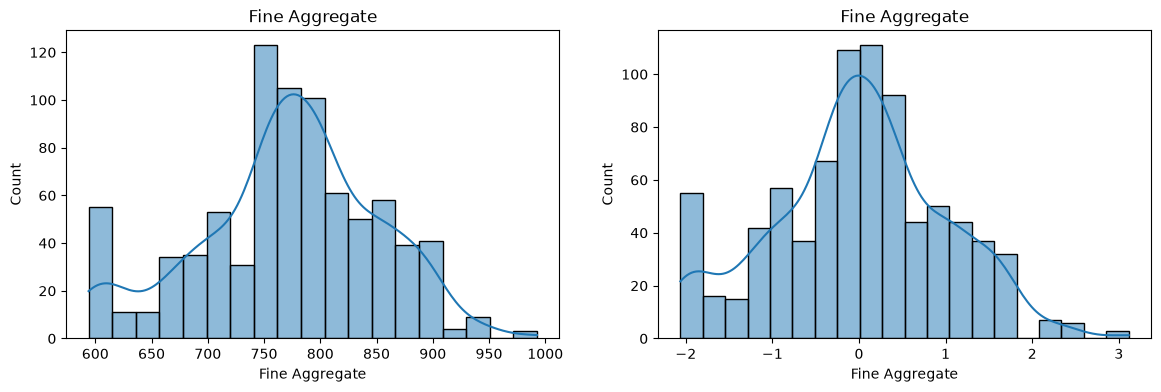

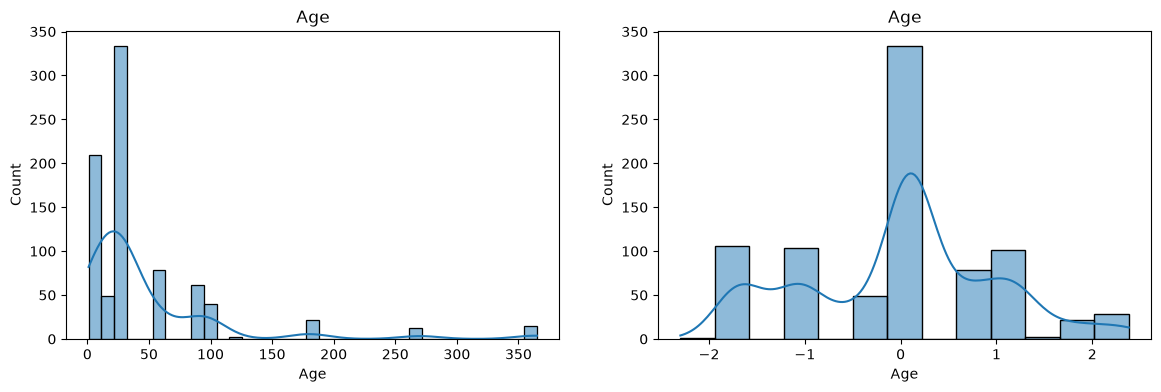

In [88]:

# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col] , kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed2[col] , kde=True)
    plt.title(col)

    plt.show()